# LSTM Autoencoder Comparison

This notebook reads the saved Day 6 experiment artifacts and turns them into a compact review flow.

It is meant to answer a practical question:

- how did the LSTM autoencoder perform against the simpler baselines?
- what does the saved run actually look like when we inspect the artifacts?

The notebook does not retrain the model.
It loads the outputs created by `python -m src.anomaly_lstm_autoencoder`.

In [1]:
import json
import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display

PROJECT_ROOT = Path.cwd()
while not (PROJECT_ROOT / "src").exists() and PROJECT_ROOT != PROJECT_ROOT.parent:
    PROJECT_ROOT = PROJECT_ROOT.parent

if not (PROJECT_ROOT / "src").exists():
    raise FileNotFoundError("Could not locate the project root containing the src directory.")

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 5)


## 1. Load a saved run

By default, this notebook loads the latest run under `Data/experiments/anomaly_day6`.

If you want a specific run, set `ANOMALY_RUN_NAME` in the environment before opening the notebook,
or edit `run_name_override` below.

In [2]:
experiment_root = PROJECT_ROOT / "Data" / "experiments" / "anomaly_day6"
run_name_override = ""
run_name_env = os.environ.get("ANOMALY_RUN_NAME", "").strip()
run_name = run_name_override.strip() or run_name_env

if not experiment_root.exists():
    raise FileNotFoundError(f"No experiment directory found at: {experiment_root}")

available_runs = sorted([path for path in experiment_root.iterdir() if path.is_dir()])
if not available_runs:
    raise FileNotFoundError(f"No saved runs found under: {experiment_root}")

if run_name:
    artifact_dir = experiment_root / run_name
    if not artifact_dir.exists():
        raise FileNotFoundError(f"Requested run was not found: {artifact_dir}")
else:
    artifact_dir = available_runs[-1]

comparison_df = pd.read_csv(artifact_dir / "comparison_metrics.csv")
window_scores_df = pd.read_csv(artifact_dir / "window_scores.csv")
row_scores_df = pd.read_csv(artifact_dir / "row_level_scores.csv")
history_df = pd.read_csv(artifact_dir / "training_history.csv")
metadata = json.loads((artifact_dir / "run_metadata.json").read_text(encoding="utf-8"))
summary_md = (artifact_dir / "day_06_summary.md").read_text(encoding="utf-8")

print(f"Loaded run: {artifact_dir.name}")
print(f"Artifacts directory: {artifact_dir}")
print(f"Best model: {metadata['best_model']['model_name']}")
print(f"Training device: {metadata['device_name']}")
print(f"Reconstruction threshold: {metadata['threshold']:.6f}")


Loaded run: smoke_save_check
Artifacts directory: c:\Users\Manikanth Reddy\Documents\LogicVeda\Project-1\Data\experiments\anomaly_day6\smoke_save_check
Best model: MAD Distance
Training device: cpu
Reconstruction threshold: 1.270194


## 2. Review the saved summary and metric table

In [3]:
display(Markdown(summary_md))
comparison_df

# Day 06 Anomaly Detection Summary

- Run name: `smoke_save_check`
- Best model: `MAD Distance`
- Best PR-AUC: `0.939986`
- Reconstruction-error threshold: `1.270194`
- Training device: `cpu`
- Final training loss: `0.942150`

## Comparison Table

| model_key | model_name | roc_auc | pr_auc | pr_curve_points |
| --- | --- | --- | --- | --- |
| mad | MAD Distance | 0.941561 | 0.939986 | 113 |
| zscore | Z-Score Distance | 0.940698 | 0.939898 | 116 |
| local_outlier_factor | Local Outlier Factor | 0.918339 | 0.921313 | 123 |
| lstm_autoencoder | LSTM Autoencoder | 0.923389 | 0.908206 | 262 |
| isolation_forest | Isolation Forest | 0.759402 | 0.672790 | 115 |

## Plain-Language Takeaway

The LSTM autoencoder learned useful temporal structure, but the simplest robust statistical method in this run was `MAD Distance`.
That means deep learning is competitive here, but not automatically better than well-chosen statistical baselines.


,model_key,model_name,roc_auc,pr_auc,pr_curve_points
0,mad,MAD Distance,0.941561,0.939986,113
1,zscore,Z-Score Distance,0.940698,0.939898,116
2,local_outlier_factor,Local Outlier Factor,0.918339,0.921313,123
3,lstm_autoencoder,LSTM Autoencoder,0.923389,0.908206,262
4,isolation_forest,Isolation Forest,0.759402,0.672790,115


## 3. Compare ROC-AUC and PR-AUC visually

For anomaly detection, `PR-AUC` is often the more useful metric when anomalies are relatively rare,
so pay extra attention to that bar chart.

C:\Users\Manikanth Reddy\AppData\Local\Temp\ipykernel_33964\676319170.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=plot_df, x="roc_auc", y="model_name", ax=axes[0], palette="Blues_r")
C:\Users\Manikanth Reddy\AppData\Local\Temp\ipykernel_33964\676319170.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=plot_df, x="pr_auc", y="model_name", ax=axes[1], palette="Greens_r")


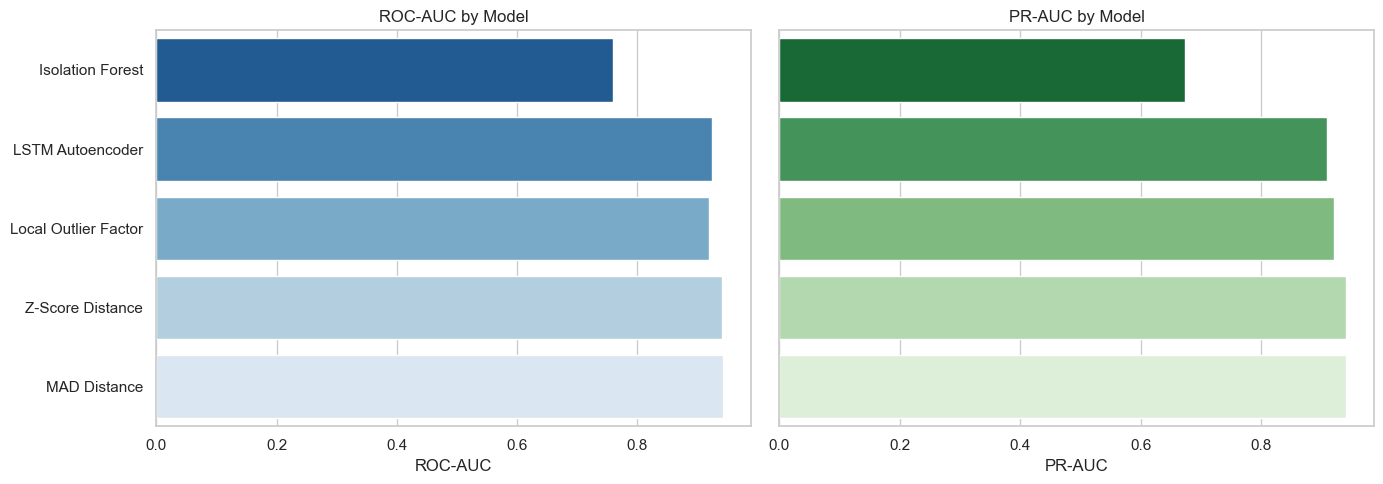

In [4]:
plot_df = comparison_df.copy()
plot_df = plot_df.sort_values("pr_auc", ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
sns.barplot(data=plot_df, x="roc_auc", y="model_name", ax=axes[0], palette="Blues_r")
axes[0].set_title("ROC-AUC by Model")
axes[0].set_xlabel("ROC-AUC")
axes[0].set_ylabel("")

sns.barplot(data=plot_df, x="pr_auc", y="model_name", ax=axes[1], palette="Greens_r")
axes[1].set_title("PR-AUC by Model")
axes[1].set_xlabel("PR-AUC")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()


## 4. Look at LSTM training behavior

This is not the final quality metric, but it helps answer whether the autoencoder actually learned to reconstruct
normal windows more consistently over training.

In [5]:
history_df

,epoch,train_loss
0,1,0.94215


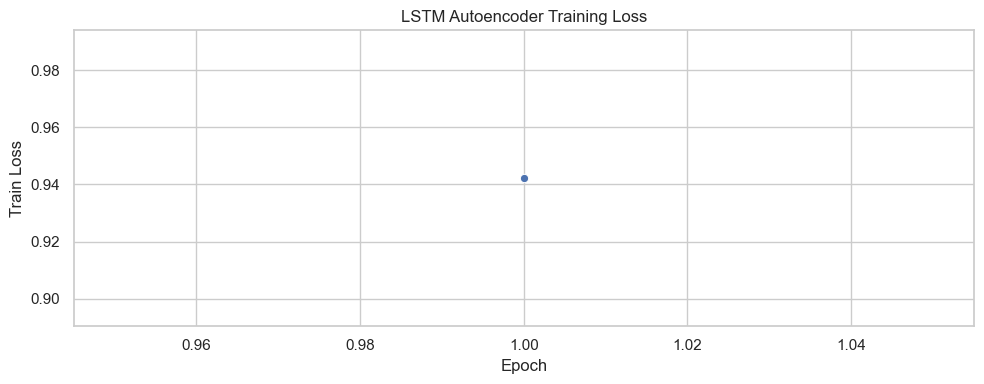

In [6]:
if not history_df.empty:
    plt.figure(figsize=(10, 4))
    sns.lineplot(data=history_df, x="epoch", y="train_loss", marker="o")
    plt.title("LSTM Autoencoder Training Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Train Loss")
    plt.tight_layout()
    plt.show()


## 5. Check score separation on anomaly vs normal windows

The goal here is not to inspect every number. The goal is to see whether anomaly windows generally receive higher scores
than normal windows for the strongest methods in the saved run.

Text(0.5, 0.98, 'Score Separation for Top Methods')

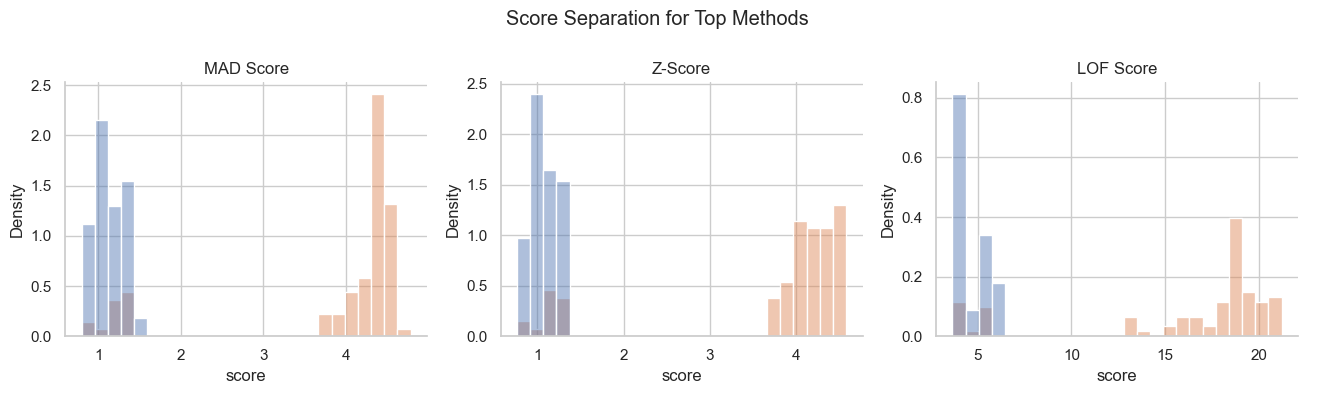

In [7]:
score_column_map = {
    "lstm_autoencoder": "reconstruction_error",
    "mad": "mad_score",
    "zscore": "zscore_score",
    "local_outlier_factor": "local_outlier_factor_score",
    "isolation_forest": "isolation_forest_score",
}

top_models = comparison_df.sort_values("pr_auc", ascending=False).head(3)
top_score_columns = [score_column_map[row.model_key] for row in top_models.itertuples()]

melt_df = window_scores_df.loc[:, ["is_anomaly_window", *top_score_columns]].melt(
    id_vars="is_anomaly_window",
    var_name="score_column",
    value_name="score",
)

column_label_map = {
    "reconstruction_error": "LSTM Reconstruction Error",
    "mad_score": "MAD Score",
    "zscore_score": "Z-Score",
    "local_outlier_factor_score": "LOF Score",
    "isolation_forest_score": "Isolation Forest Score",
}
melt_df["method"] = melt_df["score_column"].map(column_label_map)
melt_df["window_type"] = melt_df["is_anomaly_window"].map({0: "normal", 1: "anomaly"})

g = sns.FacetGrid(melt_df, col="method", sharex=False, sharey=False, height=4, aspect=1.1)
g.map_dataframe(sns.histplot, x="score", hue="window_type", bins=25, stat="density", common_norm=False, alpha=0.45)
g.add_legend()
g.set_titles("{col_name}")
g.figure.subplots_adjust(top=0.80)
g.figure.suptitle("Score Separation for Top Methods")


## 6. Quick notebook takeaway

This cell turns the saved run into a short conclusion you can reuse in the journal or report.

In [8]:
best_row = comparison_df.iloc[0]
lstm_row = comparison_df.loc[comparison_df["model_key"] == "lstm_autoencoder"].iloc[0]

takeaway = f"""
### Run takeaway

- Best model in this saved run: `{best_row['model_name']}`
- Best PR-AUC: `{best_row['pr_auc']:.6f}`
- LSTM Autoencoder PR-AUC: `{lstm_row['pr_auc']:.6f}`
- LSTM Autoencoder ROC-AUC: `{lstm_row['roc_auc']:.6f}`

Plain language:
the LSTM autoencoder is competitive, but the saved comparison should decide whether its extra complexity is justified.
If a simple robust method stays equal or better, that is an important result, not a disappointment.
"""

display(Markdown(takeaway))



### Run takeaway

- Best model in this saved run: `MAD Distance`
- Best PR-AUC: `0.939986`
- LSTM Autoencoder PR-AUC: `0.908206`
- LSTM Autoencoder ROC-AUC: `0.923389`

Plain language:
the LSTM autoencoder is competitive, but the saved comparison should decide whether its extra complexity is justified.
If a simple robust method stays equal or better, that is an important result, not a disappointment.
